In [1]:
# Create and save Datasets for training GPO-Koopman models later on
import pandas as pd
import numpy as np
import torch
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
import GPKoopman as gpk
from IPython.display import display, clear_output, HTML
import math

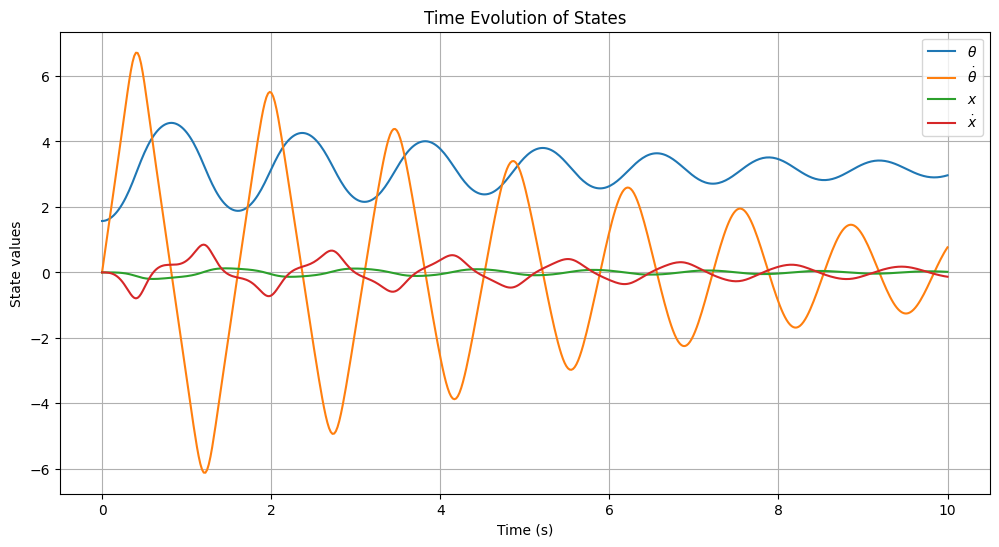

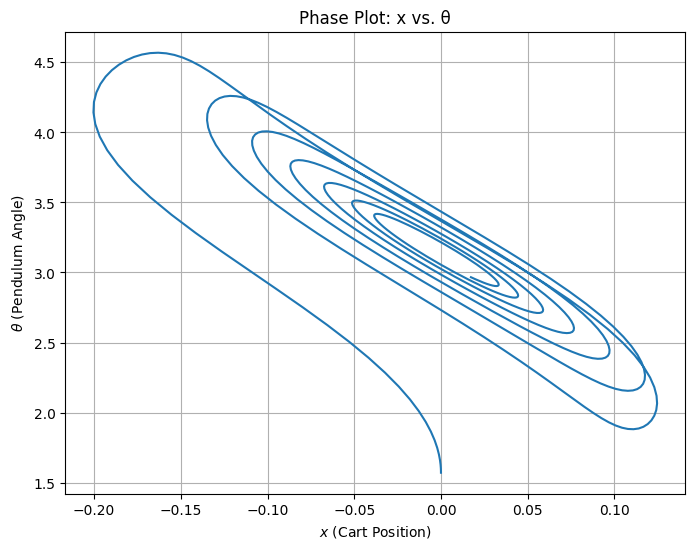

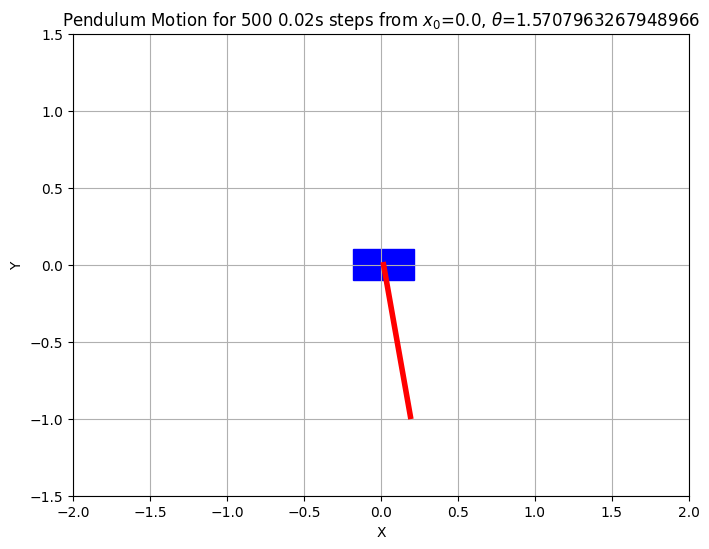

In [2]:
%matplotlib inline
# Define the initial conditions and parameters
x0 = torch.tensor([math.pi/2, 0.0, 0.0, 0.0], dtype=torch.float64)  # Initial state [theta, dtheta, x, dx]
ts = 0.02  # Time step
num_steps = 500  # Number of simulation steps
time = np.linspace(0, ts * num_steps, num_steps)  # Time array

# Define input (constant force for simplicity)
u = torch.zeros((1, num_steps), dtype=torch.float64)  # No external force

# Run simulation
states = gpk.sim_RK4_nonautonomous(gpk.fc_PoC, x0, ts, num_steps, u, params=torch.tensor([0.4, 1., 9.81, 0.5, 2., 0.1/12]))

# Plot the time evolution of the states
plt.figure(figsize=(12, 6))
labels = [r"$\theta$", r"$\dot{\theta}$", r"$x$", r"$\dot{x}$"]
for i in range(4):
    plt.plot(time, states[i, :].numpy(), label=labels[i])
plt.xlabel("Time (s)")
plt.ylabel("State values")
plt.legend()
plt.title("Time Evolution of States")
plt.grid()
plt.show()

# Phase plot (x vs. theta)
plt.figure(figsize=(8, 6))
plt.plot(states[2, :].numpy(), states[0, :].numpy())
plt.xlabel(r"$x$ (Cart Position)")
plt.ylabel(r"$\theta$ (Pendulum Angle)")
plt.title("Phase Plot: x vs. θ")
plt.grid()
plt.show()

# Animation
fig, ax = plt.subplots(figsize=(8, 6))
cart_width = 0.4
cart_height = 0.2
pendulum_length = 1.0

ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
ax.set_title(fr'Pendulum Motion for {num_steps} {ts}s steps from $x_0$={states[2,0]}, $\theta$={states[0,0]}')
ax.grid()

cart = plt.Rectangle((-cart_width/2, -cart_height/2), cart_width, cart_height, color="blue")
pendulum_line, = ax.plot([], [], lw=4, color="red")

ax.add_patch(cart)

def init():
    cart.set_xy((-cart_width/2, -cart_height/2))
    pendulum_line.set_data([], [])
    return cart, pendulum_line

def update(frame):
    x = states[2, frame].item()
    theta = states[0, frame].item()

    # Update cart position
    cart.set_xy((x - cart_width/2, -cart_height/2))

    # Update pendulum position
    pendulum_x = x + pendulum_length * np.sin(theta)
    pendulum_y = pendulum_length * np.cos(theta)
    pendulum_line.set_data([x, pendulum_x], [0, pendulum_y])

    return cart, pendulum_line

#ani = FuncAnimation(fig, update, frames=num_steps, init_func=init, blit=True, interval=20)

ani = FuncAnimation(fig, update, frames=num_steps, init_func=init, blit=True, interval=20)

# Embed animation in the notebook
#HTML(ani.to_jshtml())
ani.save('pendulum.gif', writer='pillow', fps=50)
# Display the animation
#plt.show()